# Pipeline: Reset & Populate

In [ ]:
import logging, sys
from graph_utils import NeatFormatter

_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(NeatFormatter())
logging.root.handlers = []
logging.root.addHandler(_handler)
logging.root.setLevel(logging.INFO)

from main import reset_data_file, save_graph
from populate import populate_all
from enrich import enrich_all
from reasoning import check_consistency
from graph_embedding import (
    load_object_property_triples,
    train_embedding_model,
    visualize_embeddings,
    build_entity_type_map,
    filter_predictions_by_class,
    TOP_K_PREDICTIONS,
)
from config import ONT
from graph_utils import local_name
from pykeen.predict import predict_target
from visualize import main as run_visualize


In [2]:
graph = reset_data_file()
populate_all(graph)


▸ Province
  · East_Nusa_Tenggara
  · West_Nusa_Tenggara
  · Bali

▸ Island
  · Nusa_Penida  (locatedIn: Bali)
  · Nusa_Lembongan  (locatedIn: Bali)
  · Serangan_Island  (locatedIn: Bali)
  · Menjangan_Island  (locatedIn: Bali)
  · Nusa_Ceningan  (locatedIn: Bali)
  ↳ Bali: 5 islands
  · Moyo_Island  (locatedIn: West_Nusa_Tenggara)
  · Lombok  (locatedIn: West_Nusa_Tenggara)
  · Satonda_Island  (locatedIn: West_Nusa_Tenggara)
  · Bungin_Island  (locatedIn: West_Nusa_Tenggara)
  ↳ NTB: 4 islands
  · Flores  (locatedIn: East_Nusa_Tenggara)
  · Komodo__island_  (locatedIn: East_Nusa_Tenggara)
  · Rote_Island  (locatedIn: East_Nusa_Tenggara)
  · Pamana_Island  (locatedIn: East_Nusa_Tenggara)
  · Besar_Island__Flores  (locatedIn: East_Nusa_Tenggara)
  · Dambila  (locatedIn: East_Nusa_Tenggara)
  · Pantar  (locatedIn: East_Nusa_Tenggara)
  · Palu_e  (locatedIn: East_Nusa_Tenggara)
  · Ndao_Island  (locatedIn: East_Nusa_Tenggara)
  · Dana_Island__Sabu_Raijua_  (locatedIn: East_Nusa_Tenggara)

# Enrich, Save, Reason

In [3]:
import os, sys

enrich_all(graph)
save_graph(graph)

# Suppress owlready2 stdout (java command line, HermiT timing, cyclic-type warnings)
with open(os.devnull, "w") as _devnull:
    _stdout, sys.stdout = sys.stdout, _devnull
    result = check_consistency()
    sys.stdout = _stdout

print("Ontology is", "CONSISTENT ✓" if result else "INCONSISTENT ✗")


  Country backbone: 3 provinces → Indonesia
  Added Bali_Island (manual — DBpedia has Bali as Province)
  Island → Province: 23 links (auto from DBpedia)
  wikiPageWikiLink → locatedIn: 204 links (auto)
  Created 8 Activity individuals
  hasActivity: 30 links (auto from categories + wikiLinks)
  Default activities (fallback): 44 links
  hasTouristAttraction (hub): 49 links
  hasAccommodation (hub): 5 links
  Komodo_National_Park → numberOfVisitors: 45000
  Kelimutu_National_Park → numberOfVisitors: 12507
  Mount_Rinjani_National_Park → numberOfVisitors: 117715
  West_Bali_National_Park → numberOfVisitors: 5592
  numberOfVisitors: 4 values added
  hasRating: 28 values added
  hasRating skipped (Hotel domain conflict): Amankila, Tandjung_Sari, Tjampuhan_Hotel, InterContinental_Hotel_Bali, Belmond_Jimbaran_Puri
  hasEntryFee: 15 values added
  hasEntryFee skipped (not in graph): Bali_Bird_Park, Sacred_Monkey_Forest_Sanctuary, Bali_Botanic_Garden
  establishedYear: 6 values added
  establi

* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit:/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////var/folders/1j/z8zbdmfs73j3wgb3vtt985140000gn/T/tmp5vu7hqr9 -Y


Ontology is CONSISTENT
── Individuals per populated class ──
  Province              ( 3) Bali, West_Nusa_Tenggara, East_Nusa_Tenggara
  Island                (29) Besar_Island__Flores, Flores, Lombok, Sumba, Sumbawa, Dambila …
  City                  (52) Bali, West_Nusa_Tenggara, East_Nusa_Tenggara, Central_Lombok_Regency, Central_Sumba_Regency, East_Flores_Regency …
  Beach                 ( 8) Lovina_Beach, Pandawa_Beach, Legian, Padang_Padang_Beach, Dreamland_Beach, Tanjung_Ringgit …
  Park                  ( 6) West_Bali_National_Park, Komodo_National_Park, Laiwangi_Wanggameti_National_Park, Kelimutu_National_Park, Manupeu_Tanah_Daru_National_Park, Mount_Rinjani_National_Park
  Volcano               ( 4) Bratan__volcano_, Mount_Agung, Mount_Batur, Mount_Tambora
  Museum                (11) Gedong_Arca_Museum__Bedulu, Le_Mayeur_Museum, Semarajaya_Museum, Neka_Art_Museum, Bali_Museum, Museum_Pasifika …
  Temple                ( 5) Pura_Taman_Ayun, Pura_Luhur_Batukaru, Pura_Penatara

* Owlready2 * HermiT took 2.0591928958892822 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Warning: ignoring cyclic type of, involving storid 521

* Owlready2 * Warning: ignoring cyclic type of, involving storid 529

* Owlready2 * Warning: ignoring cyclic type of, involving storid 539

* Owlready2 * Warning: ignoring cyclic type of, involving storid 541

* Owlready2 * Warning: ignoring cyclic type of, involving storid 543

* Owlready2 * Warning: ignoring cyclic type of, involving storid 526



# Graph Embedding

In [4]:
%matplotlib inline

emb_graph, base_triples = load_object_property_triples()
training_result, triples_factory = train_embedding_model(base_triples)
entity_type_map = build_entity_type_map(emb_graph)


No cuda devices were available. The model runs on CPU
Using device: None
Inferred unique=False for Embedding()
Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 400/400 [00:46<00:00,  8.56epoch/s, loss=0.334, prev_loss=0.341]

When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.



Evaluating on cpu:   0%|          | 0.00/1.18k [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Evaluating on cpu: 100%|██████████| 1.18k/1.18k [00:00<00:00, 14.9ktriple/s]

Evaluation took 0.09s seconds


Saved cluster plot → embedding_clusters.png


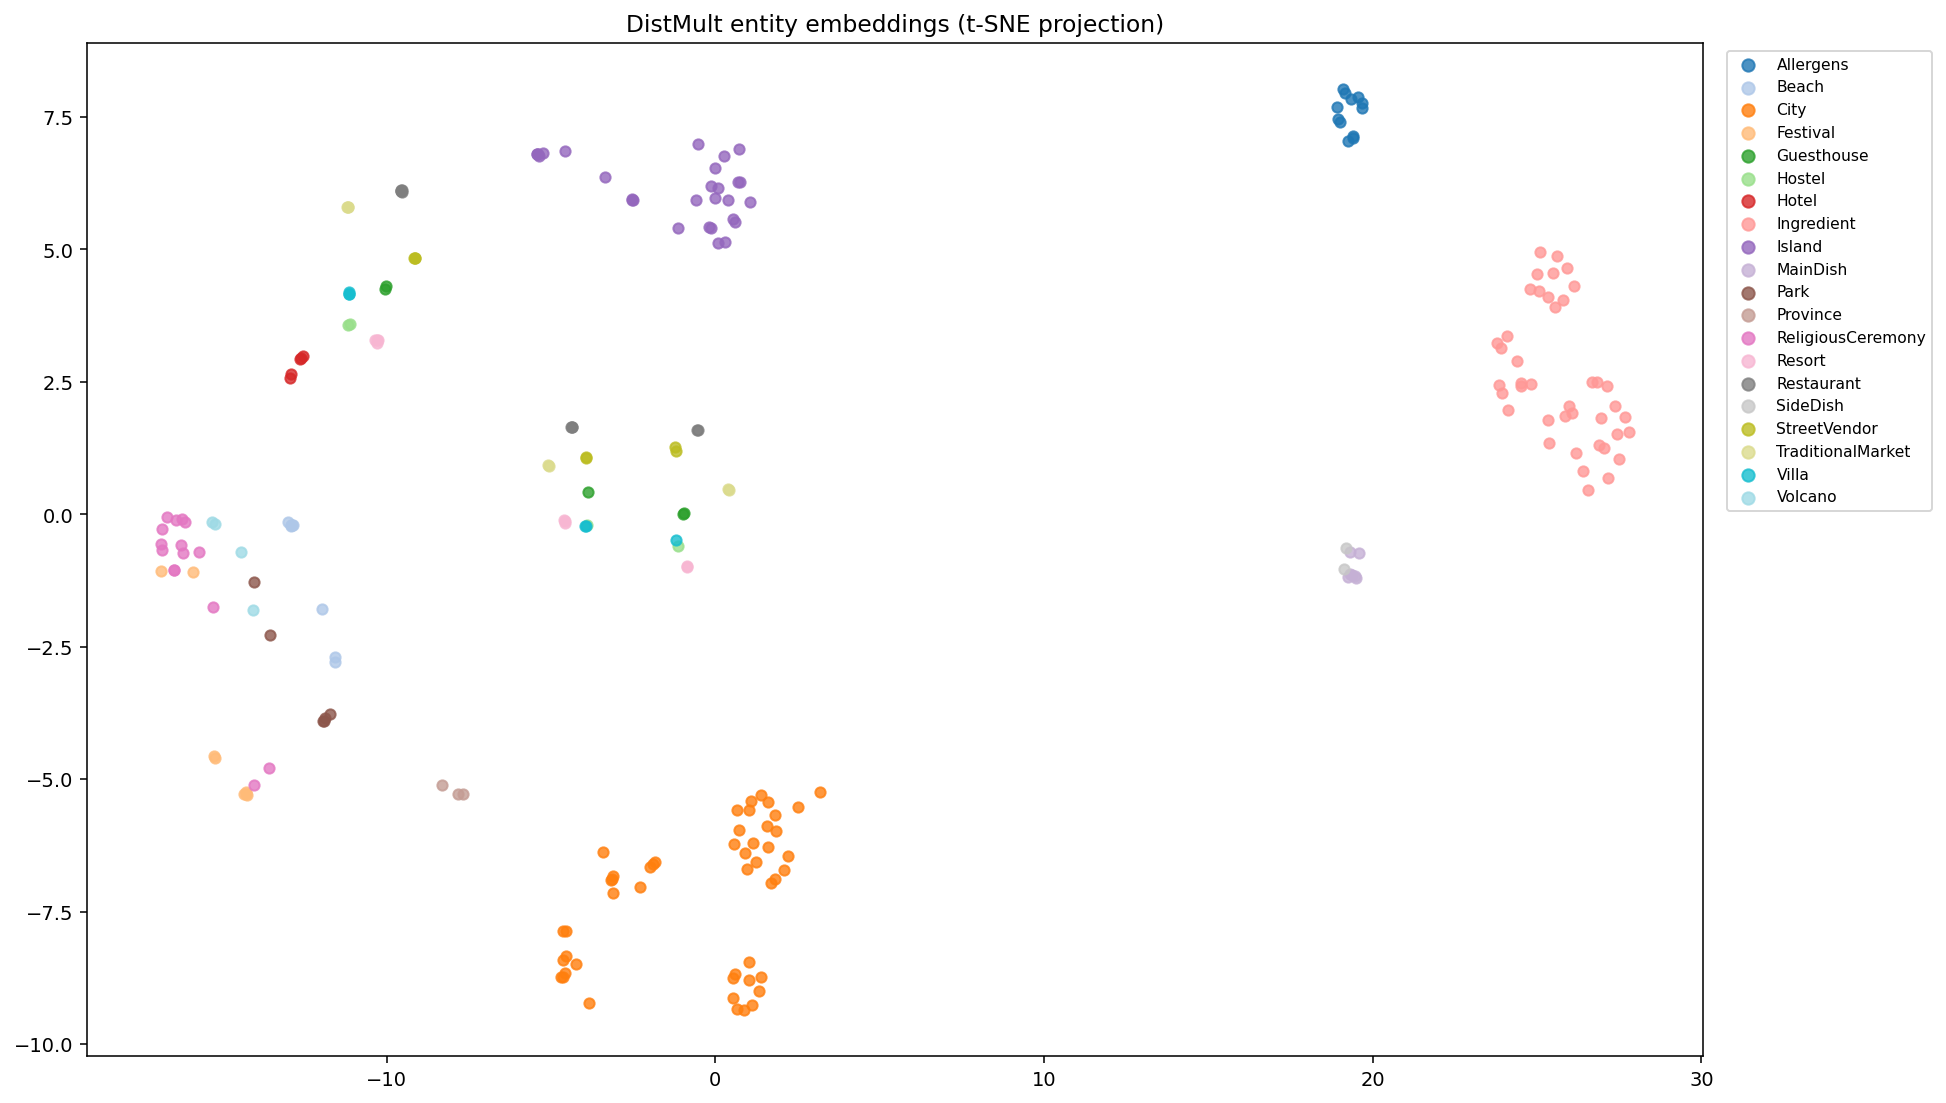

In [5]:
visualize_embeddings(training_result.model, triples_factory, emb_graph)

from IPython.display import Image, display
display(Image(filename="embedding_clusters.png"))

# Link Prediction

Change `head`, `relation`, and `expected_class` below, then re-run the cell.

In [9]:
# Define as many queries
# (head, relation, expected_class)
queries = [
    ("Praya__Lombok",   "locatedIn",   "Province"),
    # ("Pandawa_Beach",     "locatedIn",   "City"),
    # ("Barong_Dance",      "locatedIn",   "Province"),
    # ("Locavore",          "locatedIn",   "Province"),
    # ("Kecak",             "hasActivity", "Activities"),
]

for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])

    print(f"{head}  --{relation}-->  ?   [filtered to {expected_class}]")

    if head_iri not in triples_factory.entity_to_id:
        print(f"  '{head}' is not in the training data")
        continue
    if relation_iri not in triples_factory.relation_to_id:
        print(f"  '{relation}' is not a known relation")
        continue

    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)

    if valid.empty:
        print(f"  no {expected_class} candidates found")
        continue

    print(f"{"Score":>10}  Candidate")

    for _, row in valid.head(TOP_K_PREDICTIONS).iterrows():
        print(f"{row["score"]:10.4f}  {local_name(row["tail_label"])}")
    best = valid.iloc[0]
    
    print(f">> Best: {local_name(best["tail_label"])} ({best["score"]:.4f})")
    print("-" * 36)


Praya__Lombok  --locatedIn-->  ?   [filtered to Province]
     Score  Candidate
    0.1977  East_Nusa_Tenggara
   -0.0325  West_Nusa_Tenggara
   -0.1980  Bali
>> Best: East_Nusa_Tenggara (0.1977)
------------------------------------


# Save Predictions / Merge to Graph (Optional)
Review the output above, then run this cell to write the best predictions to .

In [ ]:
from rdflib import URIRef

# Collect the best prediction for each valid query
to_save = []
for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])
    if head_iri not in triples_factory.entity_to_id: continue
    if relation_iri not in triples_factory.relation_to_id: continue
    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)
    if not valid.empty:
        best_iri = valid.iloc[0]["tail_label"]
        to_save.append((head_iri, relation_iri, best_iri))

# Write to emb_graph and save data.owl
for s, p, o in to_save:
    emb_graph.add((URIRef(s), URIRef(p), URIRef(o)))
    print(f"  + {local_name(s)}  --{local_name(p)}-->  {local_name(o)}")

from config import DATA_FILE
emb_graph.serialize(destination=str(DATA_FILE), format="xml")
print(f"Saved {len(to_save)} triple(s) to data.owl")

# Network Visualization

In [8]:
run_visualize()

Nodes: 196  Edges: 463
Saved → ontology_graph.html
